In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time

import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [3]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
LUMI_SCALE = 1
version = "v39"
# for data_year in ['2022','2023','all']:
for data_year in ['all']:
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco_goodLumi.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"
path_sig = f"/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/"
mass = [1, 7, 15,23,30,40,55]
# mass = [15]
ctau = [1,10,100,1000,10000,100000]
decay = ['B', 'D','Tau']
for d in decay:
    for m in mass:
        if d == 'B' and m < 15:continue
        if d == 'Tau' and m < 7:continue
        for ct in ctau:
            fpath[f'{d}_{m}_{ct}'] = f'{path_sig}/ggH_Hto2Sto4{d}_MH-125-MS-{m}-ctauS-{ct}_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
# fpath['HV_25'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v25/normalized/HiddenValley_higgs_m_15_ctau_1000_xiO_2p5_xiL_1_23020pb_weighted.root'
# fpath['HV_25_10'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v25/normalized/HiddenValley_higgs_m_15_ctau_10000_xiO_2p5_xiL_1_23020pb_weighted.root'
# fpath['HV_26'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_Summer22EE/v26/normalized/HiddenValley_higgs_m_15_ctau_1000_xiO_2p5_xiL_1_23020pb_weighted.root'
# fpath['B']=f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v30/normalized//ggH_Hto2Sto4B_MH-125-MS-15_160000pb_weighted.root'            
# fpath['T']=f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v30/normalized//ggH_Hto2Sto4Tau_MH-125-MS-15_160000pb_weighted.root'            

            
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    if not os.path.isfile(v):continue
    root_dir = uproot.open(v) 
    if 'MuonSystem;1' not in root_dir.keys():continue

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v39/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
NEvents 182909920.0
B_15_1 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized//ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 196352350.0
B_15_10 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized//ggH_Hto2Sto4B_MH-125-MS-15-ctauS-10_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 192166910.0
B_15_100 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized//ggH_Hto2Sto4B_MH-125-MS-15-ctauS-100_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 195597000.0
B_15_1000 /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v39/normalized//ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_p

In [13]:
apply_nhits, apply_veto = 1,1


# apply selections

In [14]:
%%time

cscRechitClusterPhi = {}
cscRechitClusterSize = {}
dtRechitClusterPhi = {}
deltaPhi_cluster  = {}
cscRechitClusterDNN  = {}
dtRechitClusterSize  = {}
dtRechitClusterBX  = {}
weight = {}
sel_ev = {}
sel = {}
gLLP_ctau = {}
Puppimet = {}
dtRechitClusterMaxStation = {}

cscRechitClusterEta = {}
dtRechitClusterEta = {}

categories = ['lowMET','highMET']
# categories = ['inclusive']
region_list = ['oot', 'signal']
# v13
# thresholds = {
# 'lowMET': [160,130,2.6],
# 'highMET': [120,100,2.1],}

#v14
# thresholds = {
# 'lowMET': [160,120,2.7],
# 'highMET': [120,160,2.1],}
thresholds = {
'lowMET': [100,190,2.7],
'highMET': [130,170,2.0],}
for region in region_list:
    for tree_k in tree.keys():
        if region == 'oot' and (not tree_k == 'dataall'):continue
        T = tree[tree_k]
        
        for met_cat in categories:
            # if not (met_cat == 'highMET'):continue
            k = f'{region}_{tree_k}_{met_cat}'
            ########### SELECTION: CLUSTERS ############
            me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
            T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())
            cscRechitClusterR = (T['cscRechitClusterX'].array()**2+T['cscRechitClusterY'].array()**2)**0.5
            L1 = L1_trg(cscRechitClusterR, np.abs(T['cscRechitClusterZ'].array()), np.abs(T['cscRechitClusterSize'].array()))

            #one cluster to pass trigger
            csccluster = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
            
            csccluster = csccluster & (me1 ==0)
            csccluster = csccluster & (T['cscRechitClusterSize'].array()>thresholds[met_cat][0])
            csccluster = csccluster & (np.abs(T['cscRechitClusterEta'].array())<1.9)
            csccluster = csccluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<25)
            csccluster = csccluster & (T['cscRechitClusterJetVetoPt'].array()<30)
            csccluster = csccluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > 30) & T['cscRechitClusterMuonVetoGlobal'].array())    


            dtcluster = (T['dtRechitCluster_match_RPChits_dPhi0p5'].array() >= 1)
            dtcluster = dtcluster & (T['dtRechitClusterJetVetoPt'].array()<30)
            dtcluster = dtcluster & np.logical_not((T['dtRechitClusterMuonVetoPt'].array() > 30) & T['dtRechitClusterMuonVetoLooseId'].array())
            ###cosmic veto for DT clusters###
            
            sel_cosmic = np.logical_and(T['dtRechitClusterNOppositeSegStation1'].array()>0, T['dtRechitClusterNOppositeSegStation2'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation3'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation4'].array()>0)
            sel_cosmic = np.logical_and(sel_cosmic, T['dtRechitClusterNOppositeSegStation1'].array()+T['dtRechitClusterNOppositeSegStation2'].array()+\
                                       T['dtRechitClusterNOppositeSegStation3'].array()+T['dtRechitClusterNOppositeSegStation4'].array()>=6)
            nstation = (T['dtRechitClusterNSegStation1'].array()>1)*1+(T['dtRechitClusterNSegStation2'].array()>1)*1\
            +(T['dtRechitClusterNSegStation3'].array()>1)*1+(T['dtRechitClusterNSegStation4'].array()>1)*1
            dtcluster = dtcluster & np.logical_not(np.logical_and(nstation>=3, sel_cosmic))
            

        ########### SELECTION: EVENTS ############

            sel_ev[k] = (T['nCscRechitClusters_nocut'].array()==1) & (T['nDtRechitClusters_nocut'].array()==1)
            if "data" in k: sel_ev[k] = sel_ev[k] & T['HLT_CSCCSC'].array()
            cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),T['cscRechitClusterSize'].array())
            if apply_nhits and (not "data" in k):
                cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),1.15*T['cscRechitClusterSize'].array())

            sel_ev[k]  = np.logical_and(sel_ev[k],np.sum(cluster_pass_HLT, axis = 1) >= 1) # at least one passes HLT
            
            sel_ev[k] = np.logical_and(sel_ev[k] ,T['Puppimet'].array() < 200)
            if met_cat == 'lowMET':sel_ev[k] = np.logical_and(sel_ev[k] ,T['Puppimet'].array() < 50)
            else:sel_ev[k] = np.logical_and(sel_ev[k] ,T['Puppimet'].array() >= 50)
            sel_ev[k] = np.logical_and(sel_ev[k] ,T['nCscRings'].array()+T['nDtRings'].array()<10)
            sel_ev[k] = np.logical_and(sel_ev[k] ,T['Flag_all'].array())

            sel_ev[k] = np.logical_and(sel_ev[k] ,T['jetVeto'].array())
            sel_ev[k] = np.logical_and(sel_ev[k] ,T['Flag_ecalBadCalibFilter'].array())
            
            sel_ev[k]  = sel_ev[k] & (np.sum(dtcluster, axis = 1) == 1)
            sel_ev[k]  = sel_ev[k] & (np.sum(csccluster, axis = 1) == 1)
            
            print(k, np.count_nonzero(sel_ev[k]))
            
            
        ########### BRANCHES ############

           ##### event variables ##### 
            # make sure cluster0 and cluster1 index are different

            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[csccluster][sel_ev[k]][:,0]
            cscRechitClusterSize[k] = T['cscRechitClusterSize'].array()[csccluster][sel_ev[k]][:,0]
            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev[k]][:,0]
            dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev[k]][:,0]
            deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi[k]), np.array(dtRechitClusterPhi[k]))

            cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[csccluster][sel_ev[k]][:,0]
            dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()[dtcluster][sel_ev[k]][:,0]
            dtRechitClusterSize[k] = T['dtRechitClusterSize'].array()[dtcluster][sel_ev[k]][:,0]
            dtRechitClusterEta[k] = T['dtRechitClusterEta'].array()[dtcluster][sel_ev[k]][:,0]
            # cscRechitClusterSize1[k] = T['cscRechitClusterSize'].array()[sel_ev][cluster1][:,0]

            # if met_cat == 'lowMET':sel[k] = (np.abs(deltaPhi_cluster[k])>1.0)
            # else: 
            sel[k] = (np.abs(deltaPhi_cluster[k])>1.3)
            if 'oot' in region:sel[k] = sel[k] & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k]<0)
            elif 'invertDNN' in region: sel[k] = sel[k] & (cscRechitClusterDNN[k] < 0.96) & (cscRechitClusterDNN[k] > 0.9) &(dtRechitClusterBX[k] == 0)
            elif 'signal' in region:sel[k] = sel[k] & (cscRechitClusterDNN[k] > 0.96) & (dtRechitClusterBX[k] == 0)
            else: assert(False)


            print(k, np.count_nonzero(sel[k]))
            deltaPhi_cluster[k] = deltaPhi_cluster[k][sel[k]]
            dtRechitClusterSize[k] = dtRechitClusterSize[k][sel[k]]
            dtRechitClusterMaxStation[k] = T['dtRechitClusterMaxStation'].array()[dtcluster][sel_ev[k]][:,0][sel[k]]
            Puppimet[k] = T['Puppimet'].array()[sel_ev[k]][sel[k]]
            HMTEff = T['cscRechitClusterHMTEfficiency'].array()[csccluster][sel_ev[k]][sel[k]][:,0]
            if 'data' in k:weight[k] = (T['weight'].array())[sel_ev[k]][sel[k]]* 0.0 + 1
            elif "HV" in k:weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev[k]][sel[k]]*HMTEff*170./23.020
            else: weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev[k]][sel[k]]*HMTEff*LUMI_SCALE
            

            
            gLLP_ctau[k] = T['gLLP_ctau'].array()[sel_ev[k]][sel[k]]

            if np.count_nonzero(sel[k])<=1:continue
            print("correlation between two variables:", k, scipy.stats.pearsonr(deltaPhi_cluster[k], dtRechitClusterSize[k]))
            print("events in this region:", k, len(deltaPhi_cluster[k]), np.sum(weight[k]))

oot_dataall_lowMET 780603
oot_dataall_lowMET 44642
correlation between two variables: oot_dataall_lowMET (-0.0037540101701000676, 0.42768904393073875)
events in this region: oot_dataall_lowMET 44642 44642.0
oot_dataall_highMET 74273
oot_dataall_highMET 4483
correlation between two variables: oot_dataall_highMET (0.0019049339296639293, 0.8985369197969854)
events in this region: oot_dataall_highMET 4483 4483.0
signal_dataall_lowMET 780603
signal_dataall_lowMET 38332
correlation between two variables: signal_dataall_lowMET (0.0003670002953978821, 0.942720460779995)
events in this region: signal_dataall_lowMET 38332 38332.0
signal_dataall_highMET 74273
signal_dataall_highMET 4393
correlation between two variables: signal_dataall_highMET (0.019399762964402493, 0.19859466543264767)
events in this region: signal_dataall_highMET 4393 4393.0
signal_B_15_1_lowMET 0
signal_B_15_1_lowMET 0
signal_B_15_1_highMET 0
signal_B_15_1_highMET 0
signal_B_15_10_lowMET 0
signal_B_15_10_lowMET 0
signal_B_15_1

oot_dataall_inclusive
oot_dataall_inclusive 10.0 0.0013248542660307366
signal_dataall_inclusive
signal_dataall_inclusive 17.0 0.0022754651318431266
signal_B_15_1000_inclusive
signal_B_15_1000_inclusive 1927.3206 0.2340868530636526
0.024834156036376953


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


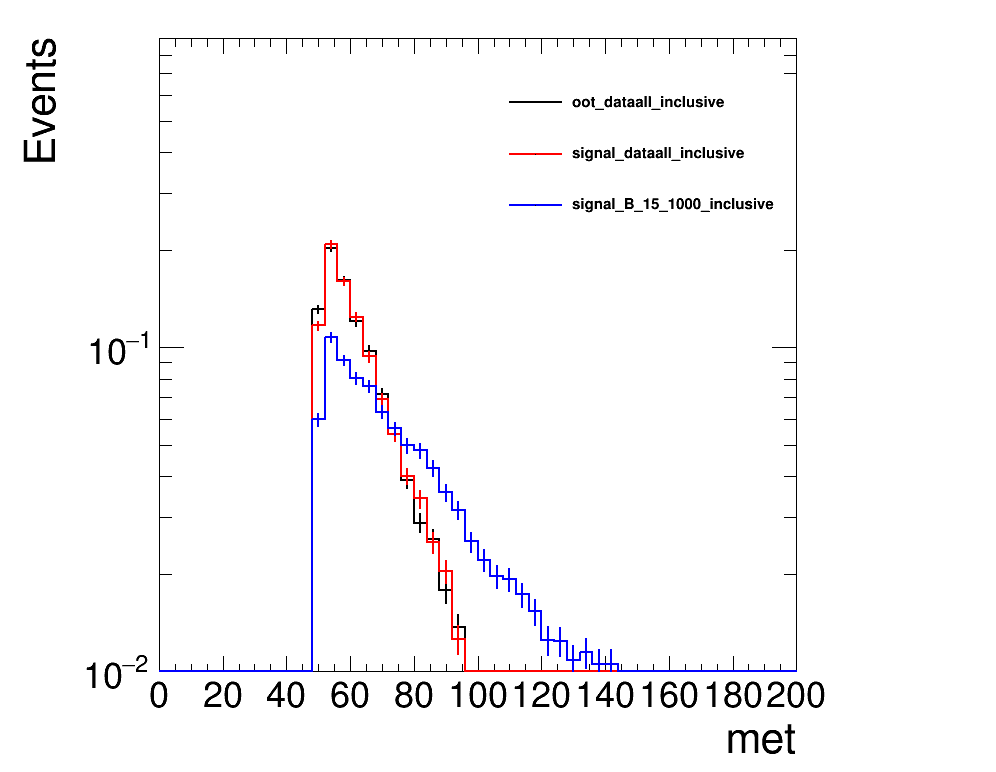

In [58]:
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
i = 0
for k in weight.keys():
    if not "1000_" in k and not "data" in k:continue
    print(k)
    # cond = (np.abs(deltaPhi_cluster[k])>1) & (cscRechitClusterDNN[k]>0.9)
    cond = (np.abs(deltaPhi_cluster[k])>=0) 
    # cond = cond & (dtRechitClusterSize[k]>=nhit) & (dtRechitClusterSize[k]<nhit_threshold)
    # cond = cond & (dtRechitClusterSize[k]>=nhit_threshold)
    h[k] = create_TH1D( np.abs(np.array(dtRechitClusterMaxStation[k][cond])), axis_title = ["max station",'Events'], binning=[5,0,5], weights = np.array(weight[k][cond]))
    # h[k] = create_TH1D( np.abs(np.array(dtRechitClusterSize[k][cond])), axis_title = ["size",'Events'], binning=[25,0,500], weights = np.array(weight[k][cond]))
    # h[k] = create_TH1D( np.abs(np.array(cscRechitClusterSize[k][cond])), axis_title = ["size",'Events'], binning=[25,0,500], weights = np.array(weight[k][cond]))
    h[k] = create_TH1D( np.array(deltaPhi_cluster[k][cond]), axis_title = ["#Delta#phi",'Events'], binning=[25,-4,4], weights = np.array(weight[k][cond]))
    h[k] = create_TH1D( np.array(Puppimet[k][cond]), axis_title = ["met",'Events'], binning=[50,0,200], weights = np.array(weight[k][cond]))
    # h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterBX[k][cond]), axis_title = ["#Delta#Phi",'Events'], binning=[20,-10,10], weights = np.array(weight[k][cond]))
    # h[nhit_threshold] = create_TH1D( np.array(dtRechitClusterMaxStation[k][cond]), axis_title = ["#Delta#Phi",'Events'], binning=[10,-5,5], weights = np.array(weight[k][cond]))
    if h[k].Integral()>0: h[k].Scale(1./h[k].Integral())
    h[k].SetLineColor(std_color_list[i])
    h[k].SetMaximum(0.9)
    h[k].SetMinimum(0.01)
    # print(nhit_threshold, np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))>=DPHI_CUT), np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))<DPHI_CUT))
    # print(k, np.count_nonzero(np.abs(np.array(deltaPhi_cluster[k][cond]))>=DPHI_CUT)/np.count_nonzero(cond))
    leg.AddEntry(h[k],k)
    h[k].Draw('histE same')
    i+=1
    cond = (dtRechitClusterSize[k]>=150) & (cscRechitClusterSize[k][sel[k]]>220) & (np.abs(deltaPhi_cluster[k])>1.5)
    # cond = dtRechitClusterMaxStation[k]>2
    print(k, np.sum(weight[k][cond]), np.count_nonzero(cond)/len(cond))
    # # nhit = nhit_threshold

    
leg.Draw()
c.SetRightMargin(0.2)
c.SetLogy()
c.Draw()

print(time.time()-start_t)

In [39]:
dt = 1
for k in weight.keys():
    if "data" in k:continue
    ######################
    signal_rate = {}
    p = 'a'
    signal_rate[p] = [0,0,0,0]
    cat =k.split('_')[-1]
    NHIT_CUT = thresholds[cat][1]
    DPHI_CUT = thresholds[cat][2]
    w = weight[k]
    a = (dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)
    b = (dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
    c = (dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
    d = (dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)

    signal_rate[p][0]+=np.sum(w[a])
    signal_rate[p][1]+=np.sum(w[b])
    signal_rate[p][2]+=np.sum(w[c])
    signal_rate[p][3]+=np.sum(w[d])
    if dt:
        
        if "high" in k: NHIT_CUT *= 1.36
        if "low" in k: NHIT_CUT *= 1.48
        cond = (dtRechitClusterSize[k]>0)
    else:
        cond = (cscRechitClusterSize[k][sel[k]] > thresholds[cat][0]*1.15)
    a = cond & (dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)
    b = cond & (dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
    c = cond & (dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
    d = cond & (dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)

    print(k, abs(1-np.sum(w[a])/signal_rate[p][0]), abs(1-np.sum(w[b])/signal_rate[p][1]), abs(1-np.sum(w[c])/signal_rate[p][2]), abs(1-np.sum(w[d])/signal_rate[p][3]))

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: invalid value encountered in true_divide


signal_B_15_1_lowMET nan nan nan nan
signal_B_15_1_highMET nan nan nan nan
signal_B_15_10_lowMET nan nan nan nan
signal_B_15_10_highMET nan nan nan nan
signal_B_15_100_lowMET nan nan nan nan
signal_B_15_100_highMET nan nan 0.0 0.0
signal_B_15_1000_lowMET 0.34828693413382783 0.3703525019113788 0.5252912072584552 0.5947446477572393
signal_B_15_1000_highMET 0.3544316222625048 0.33049502925894425 0.30375671914663616 0.3457846337601631
signal_B_15_10000_lowMET 0.36863976171605173 0.3423300985406479 0.5380947402119667 0.6691580646498962
signal_B_15_10000_highMET 0.4212789076213861 0.3301200918986089 0.2987911804551715 0.2923229778368408
signal_B_15_100000_lowMET 0.19549506737618005 nan 0.0 1.4671239875610689
signal_B_15_100000_highMET 1.0 0.0 0.0 0.5919924527877882


signal_B_15_1000_lowMET
signal_B_15_1000_highMET
0.7960848808288574


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


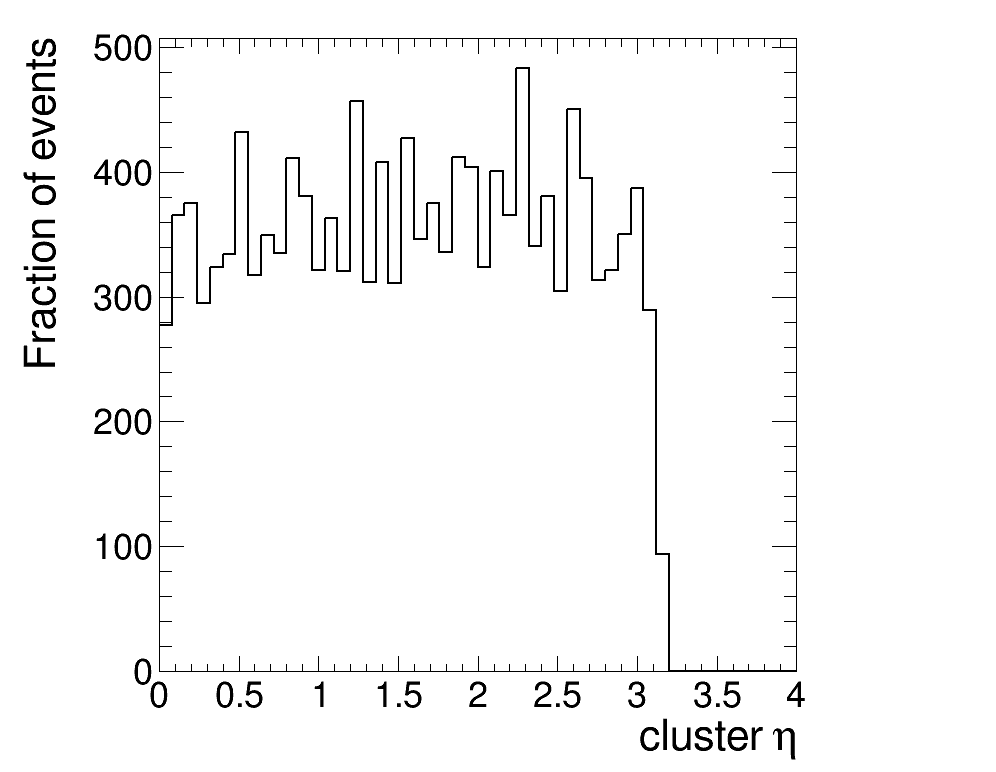

In [40]:
# Plotting ncsc
start_t = time.time()
    
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.6,0.7,0.78,0.9)
leg.SetTextSize(0.03)
leg.SetTextFont(42)
leg.SetBorderSize(0)
i = 0
dt_flag = 0
for k in cscRechitClusterEta.keys():
    if not "signal" in k:continue
    if not "_1000_" in k:continue
    if np.count_nonzero(sel[k])<50:continue
    print(k)
    if dt_flag: h[k] = create_TH1D( np.abs(np.array(dtRechitClusterPhi[k][sel[k]])), axis_title = ["cluster #eta",'Fraction of events'], binning=[50,0,4],weights = np.array(weight[k]))
    else: h[k] = create_TH1D( np.abs(np.array(cscRechitClusterPhi[k][sel[k]])), axis_title = ["cluster #eta",'Fraction of events'], binning=[50,0, 4],weights = np.array(weight[k]))
    if i == 0: h_total = h[k].Clone()
    else: h_total.Add(h[k])
    if h[k].Integral()>0: h[k].Scale(1./h[k].Integral())
    # if logy: h[k].SetMaximum(10)
    # h[k].SetMaximum(0.2)
    h[k].SetLineColor(std_color_list[i])
    leg.AddEntry(h[k],k)
    h[k].Draw('hist E1 same')
    i+=1
c.SetRightMargin(0.2)
h_total.Draw("hist")
# if logy: c.SetLogy()
# leg.Draw()
c.Draw()

# outfile = rt.TFile("DTCSC.root", "UPDATE")
# if dt_flag:h_total.Write("DtClusters")
# else: h_total.Write("CscClusters")
# outfile.Close()
# c.SaveAs(plot_dir + f"/{name}_{cluster_i}.png")
# c.SaveAs(plot_dir + f"/{name}_{cluster_i}.pdf")
# c.SaveAs(plot_dir + f"/{name}_{cluster_i}.C")
# # break


print(time.time()-start_t)


## Create datacard with OOT data

In [15]:
datacard_version = 'v18'
target_ctau = [1,3,5,10,30,50,100,300,500,1000,1500,2000,3000,5000,8000,10000,30000,50000,100000]
# target_ctau = [1000]

In [16]:
outDataCardsDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/dtcsc/{datacard_version}/"
outputTreeDir = outDataCardsDir.replace("datacards","limitTrees")
os.system(f"mkdir -p {outputTreeDir}")
os.system(f"mkdir -p {outDataCardsDir}")


signal_region = 'a'
bkg_pred = 'unblindABC'

for cat in categories:
    prefix = f'dtcsc_{cat}_'
    a, b, c, d, pred, unc_pred = {}, {}, {}, {}, {}, {}

    NHIT_CUT = thresholds[cat][1]
    DPHI_CUT = thresholds[cat][2]

    print(cat)
    ####### background prediction ######
    if bkg_pred == 'OOT':
        k = f'oot_dataall_{cat}'
        TF = len(dtRechitClusterSize[f'signal_dataall_{cat}'])/len(dtRechitClusterSize[f'oot_dataall_{cat}'])
        a[k]= 0
        a[k] = np.count_nonzero((dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)) * TF
        b[k] = np.count_nonzero((dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)) * TF
        c[k] = np.count_nonzero((dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)) * TF
        d[k] = np.count_nonzero((dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)) * TF
        if c[k] == 0: pred[k] = 999
        else: pred[k] = b[k]*d[k]/c[k]
        unc_pred[k] = (TF/c[k] + TF/b[k] + TF/d[k])**0.5*pred[k]
        print(cat, a[k],b[k],c[k],d[k], pred[k],unc_pred[k])
        bkg_rate = [pred[k],b[k],c[k],d[k]]
        observation = [pred[k],b[k],c[k],d[k]]
    else:
        k = f'signal_dataall_{cat}'
        b[k] = np.count_nonzero((dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT))
        c[k] = np.count_nonzero((dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT))
        d[k] = np.count_nonzero((dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT))
        if c[k] == 0: pred[k] = 999
        else: pred[k] = b[k]*d[k]/c[k]
        unc_pred[k] = (1/c[k] + 1/b[k] + 1/d[k])**0.5*pred[k]
        bkg_rate = [pred[k],b[k],c[k],d[k]]
        observation = [pred[k],b[k],c[k],d[k]]
    ####### signal prediction ######
    for dec in decay:
        for m in mass:
            for ct in target_ctau:
                signal_rate = {}
                mc_stat_unc = {}
                gmn = {}
                OLD_CTAU = ctau.copy()
                if '.' in str(ct):ctf = float(ct)
                else: ctf = int(ct)
                ct_list = 10**int(math.log10(ctf))

                if ctf < OLD_CTAU[0]: ct_list = [OLD_CTAU[0]]
                elif ctf>OLD_CTAU[-1]: ct_list = [OLD_CTAU[-1]]
                elif ctf in OLD_CTAU: ct_list = [ctf]
                elif len(OLD_CTAU) == 2:ct_list = OLD_CTAU.copy()
                else:ct_list = [ct_list,ct_list*10]

                p = 'signal'
                signal_rate[p] = np.zeros((4,))
                gmn[p] = np.zeros((4,))
                mc_stat_unc[p] = np.zeros((4,))


                # sig_unc[p] = []

                for i, ct0 in enumerate(ct_list):
                    k = f'{dec}_{m}_{ct0}'
                    if k not in tree.keys():continue
                    T = tree[k]
                    k = f'signal_{k}_{cat}'
                    
                    

                    if np.count_nonzero(gLLP_ctau[k])==0:continue

                    ######################

                    gLLP_ctau_sum = np.sum(gLLP_ctau[k], axis = 1)

                    weight_ctau = weight_calc(gLLP_ctau_sum, ctf/10., int(ct0)/10.) # convert everything to cm

                    if len(ct_list) == 1:weight_cond = gLLP_ctau_sum >= 0
                    else:
                        if i == 0 : weight_cond = gLLP_ctau_sum<int(ct_list[0]/2)
                        else: weight_cond = gLLP_ctau_sum>=int(ct_list[0]/2)


                    w = weight[k]*weight_ctau
                    if apply_nhits:
                        NHIT_CUT_temp = NHIT_CUT * 1.26
                        print(k, NHIT_CUT, NHIT_CUT_temp)
                        a = weight_cond & (dtRechitClusterSize[k]>=NHIT_CUT_temp) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)
                        b = weight_cond & (dtRechitClusterSize[k]>=NHIT_CUT_temp) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
                        c = weight_cond & (dtRechitClusterSize[k]<NHIT_CUT_temp) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
                        d = weight_cond & (dtRechitClusterSize[k]<NHIT_CUT_temp) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)
                    else:
                        a = weight_cond & (dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)
                        b = weight_cond & (dtRechitClusterSize[k]>=NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
                        c = weight_cond & (dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])<DPHI_CUT)
                        d = weight_cond & (dtRechitClusterSize[k]<NHIT_CUT) &  (np.abs(deltaPhi_cluster[k])>=DPHI_CUT)

                    signal_rate[p][0]+=np.sum(w[a])
                    signal_rate[p][1]+=np.sum(w[b])
                    signal_rate[p][2]+=np.sum(w[c])
                    signal_rate[p][3]+=np.sum(w[d])
                    print(signal_rate)
                    
                    sig_unc = signal_systematics(k, "dtcsc")
                    card_name = f'ggH_HToSS_STo4{dec}_ms{m}_ctau{ct}_nhits{NHIT_CUT}_dphi'+str(round(DPHI_CUT,1)).replace(".","p") + f'_{cat}'
    #                 ## create datacards ##
                    make_datacard_2tag(
                    outDataCardsDir,
                    card_name,
                    signal_rate,
                    np.sum(signal_rate['signal']),
                    bkg_rate,
                    observation,
                    [], 
                    [], 
                    sig_unc, 
                    signal_region, 
                    prefix)




lowMET
signal_B_15_100_lowMET 190 239.4
{'signal': array([0.00000000e+00, 0.00000000e+00, 2.56453157e-11, 1.51424004e-07])}
[0.0343, 0.0132, 0.0125, 0.0337, 0.0285, 0.0109, 0.0101, 0.0278]
[0.067, 0.067, 0.067, 0.067, 0.046, 0.046, 0.046, 0.046]
signal_B_15_100_lowMET 190 239.4
{'signal': array([0.00000000e+00, 0.00000000e+00, 6.12265376e-06, 5.02630835e-04])}
[0.0343, 0.0132, 0.0125, 0.0337, 0.0285, 0.0109, 0.0101, 0.0278]
[0.067, 0.067, 0.067, 0.067, 0.046, 0.046, 0.046, 0.046]
signal_B_15_100_lowMET 190 239.4
{'signal': array([0.        , 0.        , 0.03557149, 0.11830597])}
[0.0343, 0.0132, 0.0125, 0.0337, 0.0285, 0.0109, 0.0101, 0.0278]
[0.067, 0.067, 0.067, 0.067, 0.046, 0.046, 0.046, 0.046]
signal_B_15_100_lowMET 190 239.4
{'signal': array([0., 0., 0., 0.])}
[0.0343, 0.0132, 0.0125, 0.0337, 0.0285, 0.0109, 0.0101, 0.0278]
[0.067, 0.067, 0.067, 0.067, 0.046, 0.046, 0.046, 0.046]
signal_B_15_1000_lowMET 190 239.4
{'signal': array([142.68309021,  45.81100082, 230.6177063 , 537.854

In [7]:
print(outDataCardsDir,card_name,)

/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/dtcsc/v16/ ggH_HToSS_STo4B_ms55_ctau100000_nhits160_dphi2p1_highMET
